# TASK 3 - K-Nearest Neighbors (KNN)

In [2]:

import pandas as pd

# Load features
X_train = pd.read_csv("../data/2_processed/X_train.csv")
X_test  = pd.read_csv("../data/2_processed/X_test.csv")

# Load targets
y_train = pd.read_csv("../data/2_processed/y_train.csv")
y_test  = pd.read_csv("../data/2_processed/y_test.csv")

In [3]:
y_train = y_train.iloc[:, 0]
y_test  = y_test.iloc[:, 0]

In [4]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (455, 17)
X_test: (114, 17)
y_train: (455,)
y_test: (114,)


In [5]:
print("y_train unique:", y_train.unique())
print("y_test unique:", y_test.unique())

y_train unique: [1 0]
y_test unique: [0 1]


### 3.1 Train KNN classifiers for k = 1 to 20. Record test accuracy for each k

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


k_values = range(1, 21)
accuracies = []

for k in k_values:
    
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    accuracies.append(acc)
    
    print(f"k = {k:2d} | Test Accuracy = {acc:.4f}")

k =  1 | Test Accuracy = 0.9123
k =  2 | Test Accuracy = 0.8684
k =  3 | Test Accuracy = 0.9211
k =  4 | Test Accuracy = 0.8860
k =  5 | Test Accuracy = 0.9386
k =  6 | Test Accuracy = 0.9035
k =  7 | Test Accuracy = 0.9211
k =  8 | Test Accuracy = 0.8860
k =  9 | Test Accuracy = 0.9386
k = 10 | Test Accuracy = 0.9211
k = 11 | Test Accuracy = 0.9474
k = 12 | Test Accuracy = 0.9298
k = 13 | Test Accuracy = 0.9211
k = 14 | Test Accuracy = 0.9298
k = 15 | Test Accuracy = 0.9298
k = 16 | Test Accuracy = 0.9386
k = 17 | Test Accuracy = 0.9386
k = 18 | Test Accuracy = 0.9123
k = 19 | Test Accuracy = 0.9298
k = 20 | Test Accuracy = 0.9298


### 3.2- Plot accuracy vs k

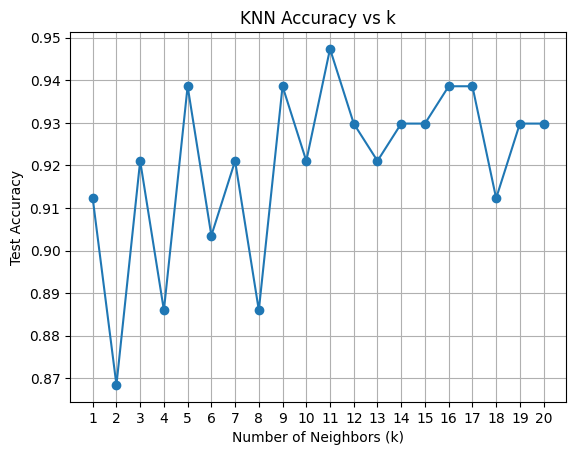

In [7]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(k_values, accuracies, marker='o')

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Test Accuracy")
plt.title("KNN Accuracy vs k")

plt.xticks(k_values)
plt.grid()
plt.show()

### Identify Optimal k

In [8]:
import numpy as np
best_k = k_values[np.argmax(accuracies)]
best_acc = max(accuracies)

print(f"Optimal k = {best_k}")
print(f"Best Accuracy = {best_acc:.4f}")

Optimal k = 11
Best Accuracy = 0.9474


The accuracy of the KNN model was evaluated for values of k ranging from 1 to 20 and visualized using an accuracy vs k plot. 
The plot shows that performance improves initially and reached a peak at k =16, after which the accuracy gradually declines as k increases

This behavior indicates that smaller values of k better capture the local structure of the data, while larger values lead to overly smooth decision boundaries and reduced model performance.

k=11 was selected as the optimal number of neigbors,achieving the highest test accuracy of 94.74%

### 3.3- Train Final model 

In [9]:
knn_final = KNeighborsClassifier(n_neighbors=3)
knn_final.fit(X_train, y_train)

y_pred_final = knn_final.predict(X_test)

#### Classification report

In [10]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90        42
           1       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



- Class 0 = Benign: Precision = 0.87, Recall = 0.93, F1-score = 0.90
- Class 1 = Malignant: Precision = 0.96, Recall = 0.92, F1-score = 0.94

The final KNN model with k = 3 achieved an overall accuracy of 92%. 
The classification report indicates strong and balanced performance across both classes. 
The model achieved particularly high precision for malignant cases (96%), meaning that most predicted malignant tumors were correctly identified. 
Additionally, the recall of 92% for malignant tumors shows that the model was effective at detecting positive cancer cases with relatively few missed diagnoses.

#### Confusion Matrix

In [11]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_final)
print(cm)

[[39  3]
 [ 6 66]]


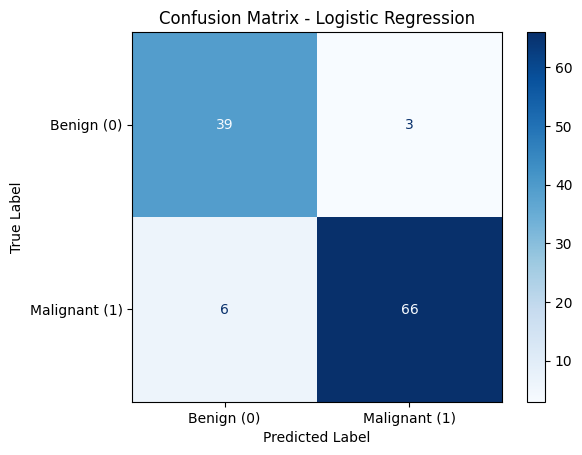

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign (0)", "Malignant (1)"]
)

disp.plot(cmap="Blues", values_format='d')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

The confusion matrix further confirms the strong performance of the model, with only 6 false negatives, which is important in a medical context where failing to detect malignant cases can have serious consequences. The model also produced only 3 false positives, indicating strong overall classification accuracy and balanced predictive capability.

The Logistic Regression model demonstrates strong predictive performance and is well-suited for medical classification tasks where recall and reliable detection of malignant tumors are critical.

<font color=red>**Conclusion** </font>: Logistic Regression provides a robust and interpretable approach to classification and performed very well on the breast cancer dataset. The model achieved an accuracy of approximately 92%, demonstrating strong predictive capability across both benign and malignant classes. The confusion matrix indicates a low number of false positives and false negatives, making the model particularly suitable for healthcare applications where accurate detection of malignant tumors is essential. Overall, Logistic Regression proved to be an effective and reliable classifier for this task.